In [1]:
import os
import sys
import pickle
import argparse
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import loguniform

sys.path.insert(1, 'scripts')
sys.path.insert(1, 'stella')

import stella

2025-01-30 00:09:58.937450: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/astro/phrdhx/micromamba/envs/nets2/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/astro/phrdhx/.lightkurve/cache. Please move all the files in the legacy directory /home/astro/phrdhx/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


## Load dataset

In [2]:
with open("../datasets/comets-plus-extras-sines-2.5-3.pkl", "rb") as file:
    ds = pickle.load(file)

In [3]:
data = ds['dataset']

In [4]:
cnn = stella.ConvNN(
    output_dir='../cnn-models/',
    ds=data)

In [5]:
modelname = '../cnn-models/ensemble_s0001_i0200_b0.63.h5'

In [6]:
cnn.load_model(modelname)

314/314 [==============================] - 1s 2ms/step


---
## Test on lightcurves

In [7]:
import lightkurve as lk
import stella

In [8]:
def predictandplot(target, sector=None, mission='TESS', pipeline='TESS-SPOC', model='../cnn-models/ensemble_s0133_i0200_b0.56.h5'):
    # Download lightcurve based on target and sector (if provided)
    if sector is None:
        lc = lk.search_lightcurve(target, mission=mission, author=pipeline)[0].download()
    else:
        lc = lk.search_lightcurve(target, sector=sector, mission=mission, author=pipeline).download()

    lc = lc[lc.quality.value == 0]
    # Process the flux
    f = np.array((lc.flux.value / np.nanmedian(lc.flux.value)) - 1)
    f = np.array(f / np.nanstd((lc.flux.value / np.nanmedian(lc.flux.value)) - 1))
    f = f + 1
    f = f[~np.isnan(f)]  # Remove NaNs
    f = (f - np.min(f)) / (np.max(f) - np.min(f))  # Normalize flux
    
    # Find the minimum length of the time, flux, and error arrays
    min_len = min(len(lc.time.value), len(f), len(lc.flux_err.value))

    # Slice the arrays to the same length to avoid broadcasting errors
    times = lc.time.value[:min_len]
    fluxes = f[:min_len]
    errs = lc.flux_err.value[:min_len]

    # Run prediction using the aligned time, flux, and error arrays
    cnn.predict(modelname=model, times=times, fluxes=fluxes, errs=errs)
    
    # Plotting the results
    plt.figure(figsize=(10, 4))
    plt.scatter(cnn.predict_time[0], cnn.predict_flux[0], c=cnn.predictions[0], vmin=0, vmax=1, s=5)
    plt.colorbar(label='Probability of Exocomet')
    plt.xlabel('Time')
    plt.ylabel('Min-Max Scaled Flux')
    plt.gcf().patch.set_alpha(0.5)
    plt.tight_layout()
    plt.show()

In [9]:
#predictandplot('Beta Pic',6)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.19it/s]


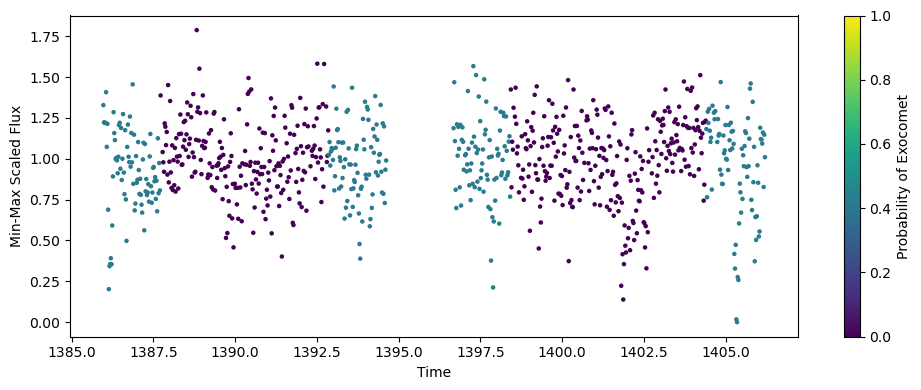

In [10]:
predictandplot('HD 22946',model='../cnn-models/ensemble_s0182_i0200_b0.56.h5')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.19it/s]


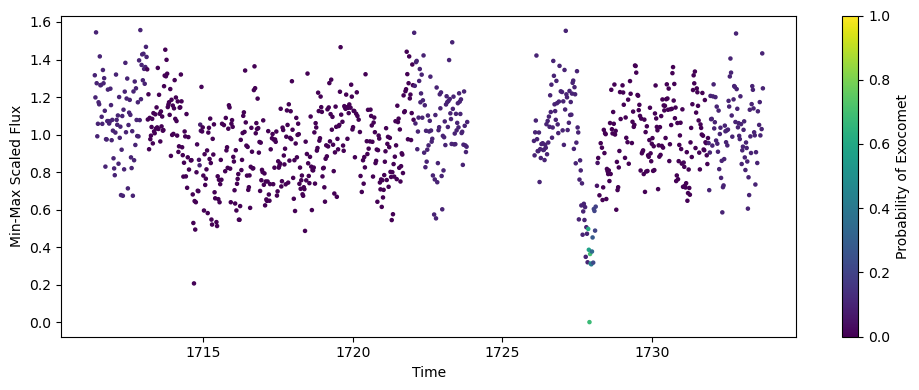

In [11]:
predictandplot('TIC 229790952',pipeline='QLP',sector=15,model='../cnn-models/ensemble_s0023_i0200_b0.81.h5')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.19it/s]


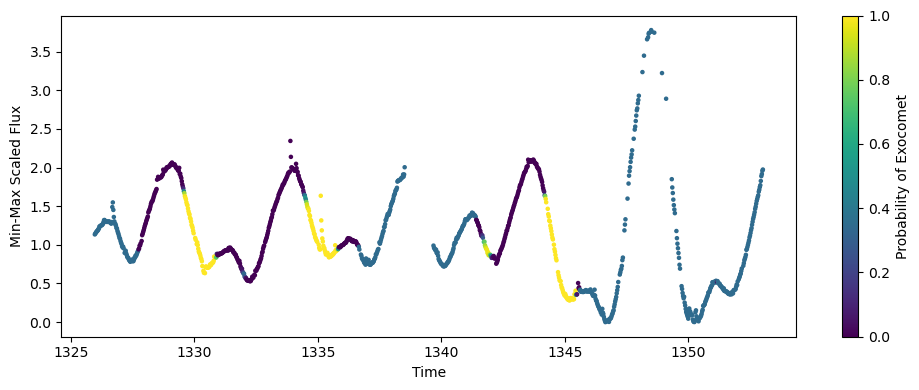

In [12]:
predictandplot('AU Mic',model='../cnn-models/ensemble_s0202_i0200_b0.58.h5')

In [13]:

from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_model_evolution(target, models, titles, sector=None, mission='TESS', pipeline='TESS-SPOC', figsize=(10,8)):
    """
    Plot the evolution of model predictions across different training iterations.
    
    Parameters
    ----------
    target : str
        Target name (e.g., "Beta Pic")
    models : list
        List of paths to different model iterations
    titles : list
        List of titles describing each model iteration
    sector : int, optional
        Specific sector to analyse. Also used as the Campaign/Quarter for Kepler
    mission : str, optional
        Mission name (default: 'TESS')
    pipeline : str, optional
        Pipeline name (default: 'TESS-SPOC')
    figsize : tuple, optional
        Figure size (default: (15, 12))
    """
    # Download and process lightcurve
    if sector is None:
        lc = lk.search_lightcurve(target, mission=mission, author=pipeline)[0].download()
    elif mission != 'TESS':
        lc = lk.search_lightcurve(target, quarter=sector, mission=mission).download()
        lc = lc[lc.sap_quality == 0]
    else:
        lc = lk.search_lightcurve(target, sector=sector, mission=mission, author=pipeline).download()
        lc = lc[lc.quality.value == 0]
    
    # Process the flux
    f = np.array((lc.flux.value / np.nanmedian(lc.flux.value)) - 1)
    f = np.array(f / np.nanstd((lc.flux.value / np.nanmedian(lc.flux.value)) - 1))
    f = f + 1
    f = f[~np.isnan(f)]
    f = (f - np.min(f)) / (np.max(f) - np.min(f))
    
    # Align arrays
    min_len = min(len(lc.time.value), len(f), len(lc.flux_err.value))
    times = lc.time.value[:min_len]
    fluxes = f[:min_len]
    errs = lc.flux_err.value[:min_len]
    
    # Create subplot grid
    fig, axes = plt.subplots(len(models), 1, figsize=figsize)
    plt.style.use('seaborn-v0_8-paper')
    fig.suptitle(f'Model Evolution for {target}', fontsize=16, y=1.02)
    
    # Plot each model's predictions
    for i, (model_path, title, ax) in enumerate(zip(models, titles, axes)):
        cnn.predict(modelname=model_path, times=times, fluxes=fluxes, errs=errs)
        
        scatter = ax.scatter(cnn.predict_time[0], cnn.predict_flux[0], 
                           c=cnn.predictions[0], vmin=0, vmax=1, s=5,
                           cmap='viridis')
        ax.grid(False)
        # Add colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='2%', pad=0.05)
        plt.colorbar(scatter, cax=cax, label='Probability')
        
        # Customize subplot
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel('Time (BJD - 2457000)' if i == len(models)-1 else '')
        ax.set_ylabel('Normalized Flux')
        
    plt.tight_layout()
    plt.show()
    return fig


In [87]:
models = [
    '../cnn-models/ensemble_s0001_i0200_b0.63.h5',
    '../cnn-models/ensemble_s0123_i0200_b0.81.h5',
    '../cnn-models/ensemble_s0051_i0200_b0.48.h5',
    '../cnn-models/ensemble_s0074_i0200_b0.63.h5',
    '../cnn-models/ensemble_s0401_i0200_b0.56.h5',
    '../cnn-models/ensemble_s0506_i0200_b0.55.h5',
    '../cnn-models/ensemble_s0532_i0150_b0.55.h5'
]

titles = [
    'Stage 1: Comets vs Non-comets',
    'Stage 2: + Planets & Binaries & Reverse shapes',
    'Stage 3: + Sines',
    'Stage 4: + SVC (replaced Sines)',
    'Stage 5: RNN',
    'Stage 6: Three-layer CNN',
    'Stage 7: Three-layer CNN: different filters'
]



100%|████████████████████████████████| 1/1 [00:00<00:00,  5.68it/s]


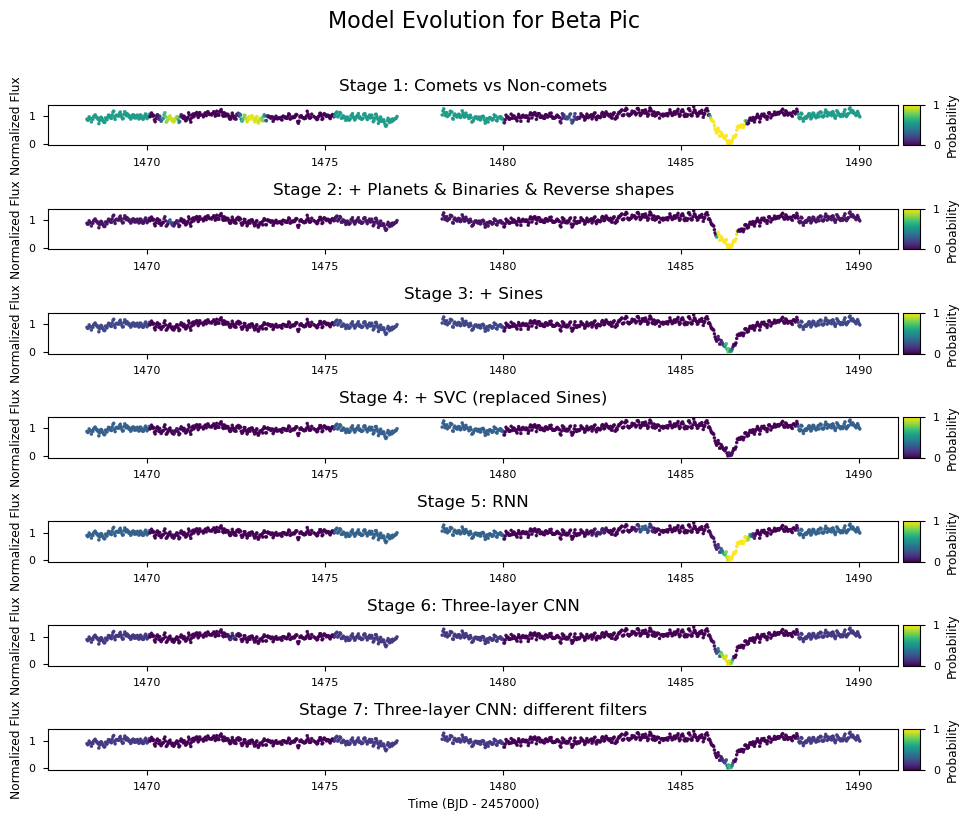

In [88]:
fig = plot_model_evolution('Beta Pic', models, titles,sector=6)
plt.show()

100%|████| 1/1 [00:00<00:00,  3.85it/s]


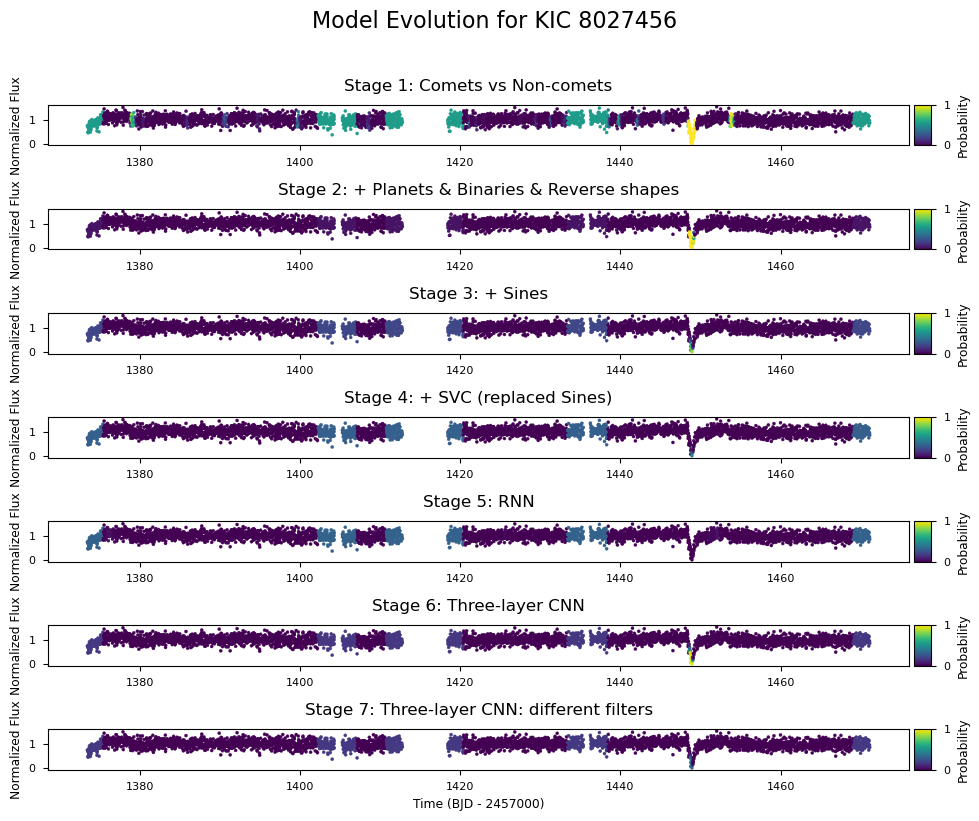

In [79]:
plot_model_evolution('KIC 8027456', models, titles, mission='Kepler',sector=15,pipeline='Kepler')
plt.show()

100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.26it/s]


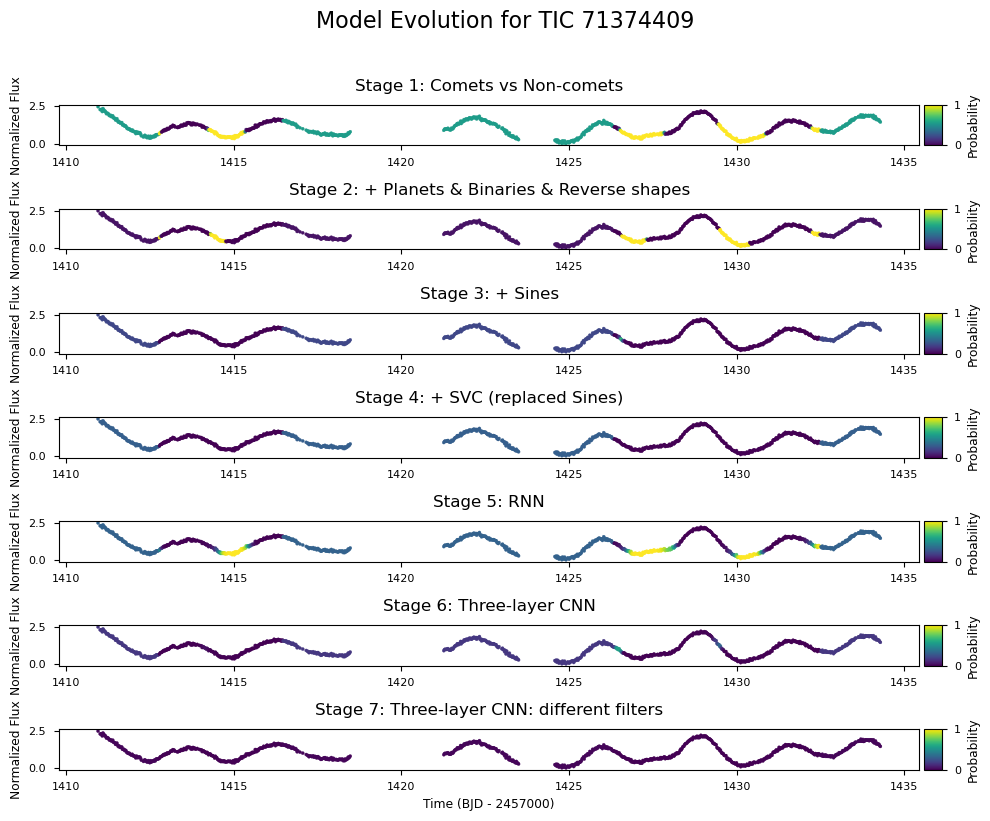

In [51]:
plot_model_evolution('TIC 71374409',models, titles)
plt.show()

100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.93it/s]


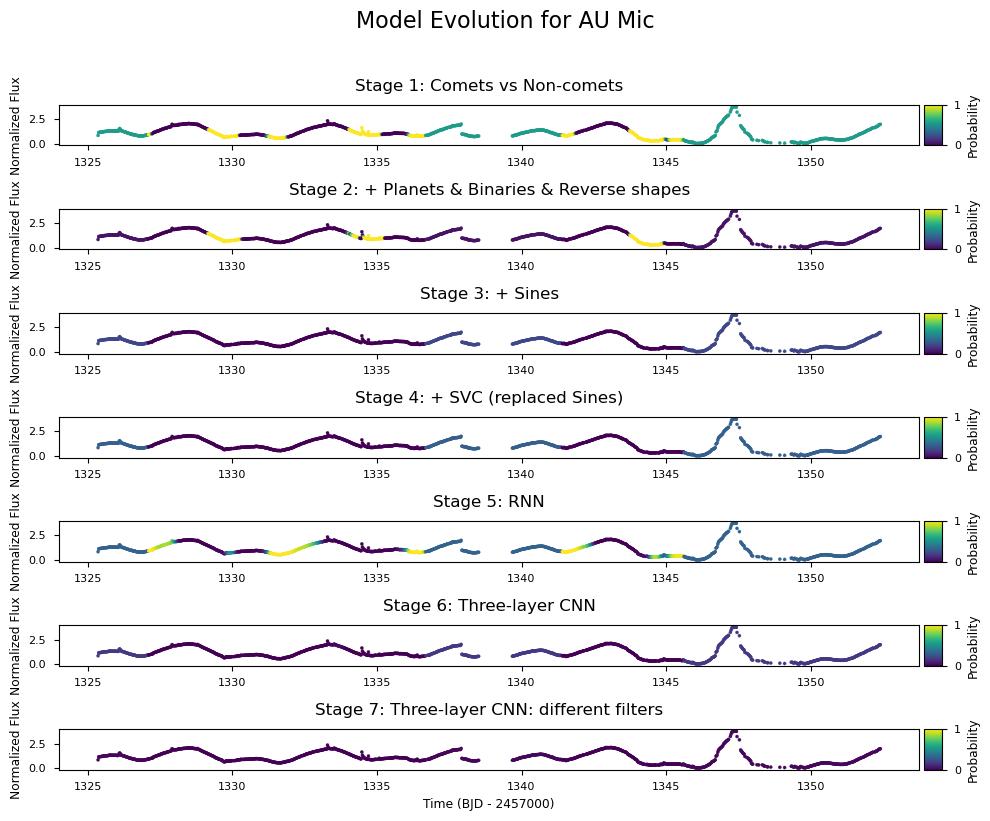

In [46]:
plot_model_evolution('AU Mic', models, titles)
plt.show()

100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.91it/s]


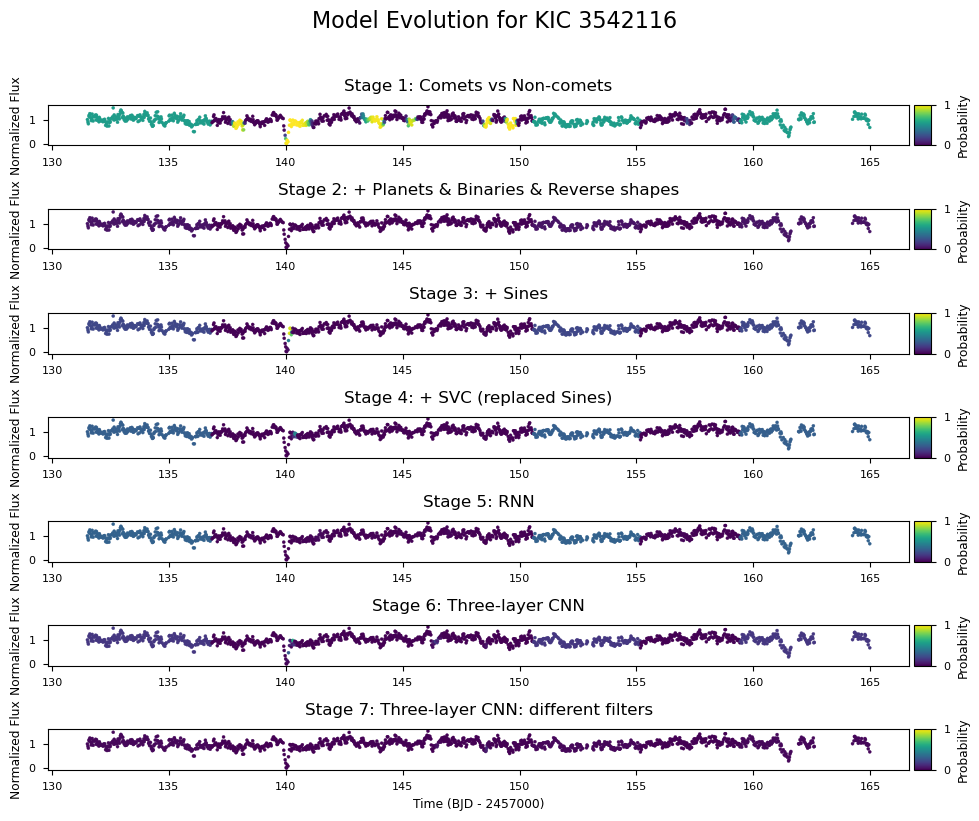

In [47]:
plot_model_evolution('KIC 3542116', models, titles, mission='Kepler',sector=1,pipeline='Kepler')
plt.show()